# IMPORT LIBRARIES 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

Matplotlib is building the font cache; this may take a moment.


# LOAD DATASET

In [12]:
df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1",
    engine="python"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## DATASET INFORMATION

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## CHECK MISSING VALUES

In [14]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## CONVERT DATE COLUMN

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

## CREATE DAILY SALES DATASET

In [16]:
sales = df.groupby("Order Date")["Sales"].sum()

sales.head()

Order Date
2014-01-03      16.448
2014-01-04     288.060
2014-01-05      19.536
2014-01-06    4407.100
2014-01-07      87.158
Name: Sales, dtype: float64

## PLOT SALES TREND

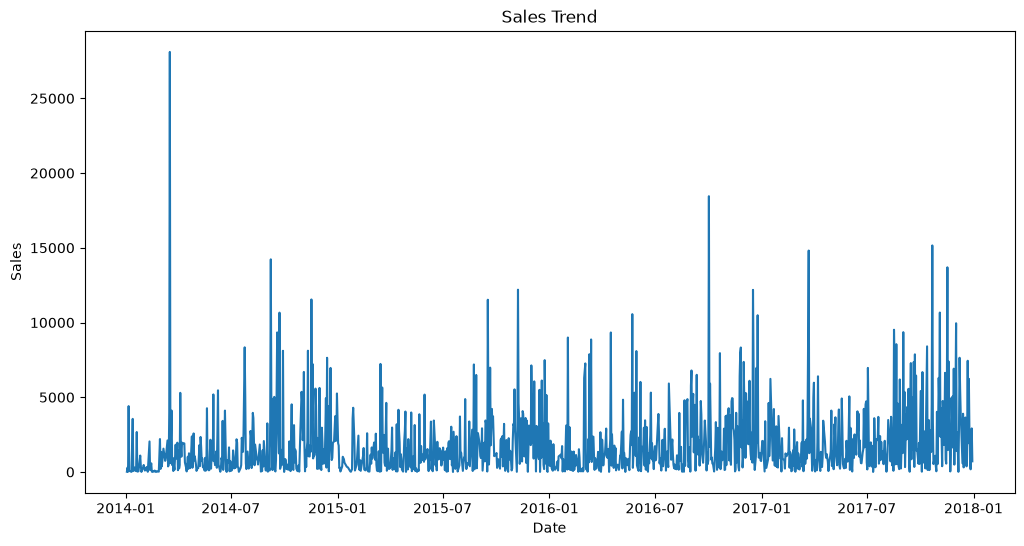

In [17]:
plt.figure(figsize=(12,6))
plt.plot(sales)
plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## PREPARE DATA FOR MACHINE LEARNING


In [18]:
sales_df = sales.reset_index()

sales_df["Days"] = (
    sales_df["Order Date"]
    - sales_df["Order Date"].min()
).dt.days

sales_df.head()

,Order Date,Sales,Days
0,2014-01-03,16.448,0
1,2014-01-04,288.060,1
2,2014-01-05,19.536,2
3,2014-01-06,4407.100,3
4,2014-01-07,87.158,4


## TRAIN MODEL

In [19]:
X = sales_df[["Days"]]
y = sales_df["Sales"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.93]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Days']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1161
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## PREDICT SALES

In [20]:
sales_df["Predicted Sales"] = model.predict(X)

sales_df.head()

,Order Date,Sales,Days,Predicted Sales
0,2014-01-03,16.448,0,1161.127098
1,2014-01-04,288.060,1,1162.057911
2,2014-01-05,19.536,2,1162.988724
3,2014-01-06,4407.100,3,1163.919537
4,2014-01-07,87.158,4,1164.850350


## FORECASTING GRAPH

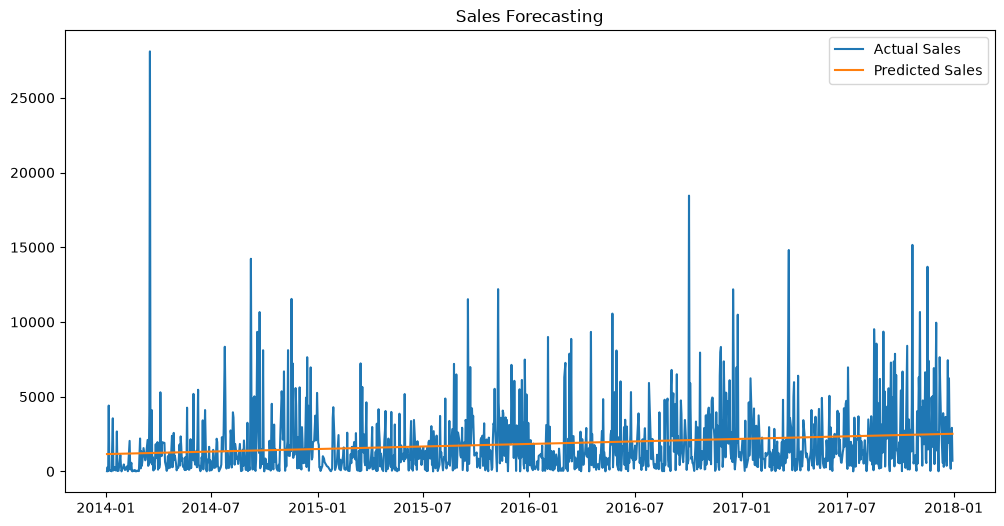

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    sales_df["Order Date"],
    sales_df["Sales"],
    label="Actual Sales"
)

plt.plot(
    sales_df["Order Date"],
    sales_df["Predicted Sales"],
    label="Predicted Sales"
)

plt.legend()
plt.title("Sales Forecasting")
plt.show()

## MODEL ERROR

In [22]:
mae = mean_absolute_error(
    sales_df["Sales"],
    sales_df["Predicted Sales"]
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1525.6238656501828


## FUTURE FORECASTING

In [23]:
future_days = np.array([[1500],[1550],[1600]])

future_sales = model.predict(future_days)

print(future_sales)

[2557.34665602 2603.88730795 2650.42795988]


C:\Users\H P\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## CREATE TIME FEATURES

In [24]:

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

df[['Order Date','Year','Month','Quarter']].head()

,Order Date,Year,Month,Quarter
0,2016-11-08,2016,11,4
1,2016-11-08,2016,11,4
2,2016-06-12,2016,6,2
3,2015-10-11,2015,10,4
4,2015-10-11,2015,10,4


## MONTHLY SALES

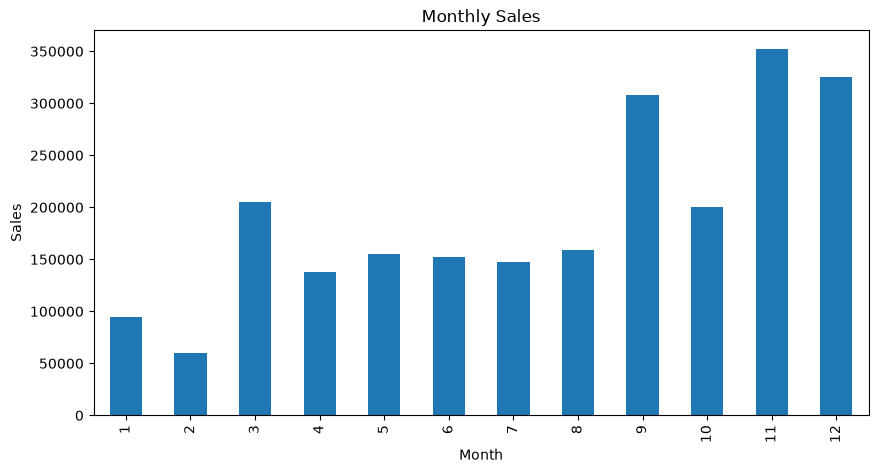

In [25]:


monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='bar', figsize=(10,5))

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

## CONCLUSION

The sales forecasting model was developed using historical sales data from the Superstore dataset.

Key findings:
- No missing values were found in the dataset.
- Sales trends were visualized over time.
- Time-based features were created from order dates.
- A Linear Regression model was trained to forecast future sales.
- The model achieved a Mean Absolute Error (MAE) of approximately 1525.
- Future sales forecasts were generated successfully.

This project demonstrates how machine learning can be used to support business planning and sales forecasting.